# Image Processing Tasks
This notebook covers convolution, first-order, and second-order edge detection.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tools
import my_functions_tp02 as my_func


## Task 1 & 2: Averaging Filter, Strides/Dilations, and Filter Automation

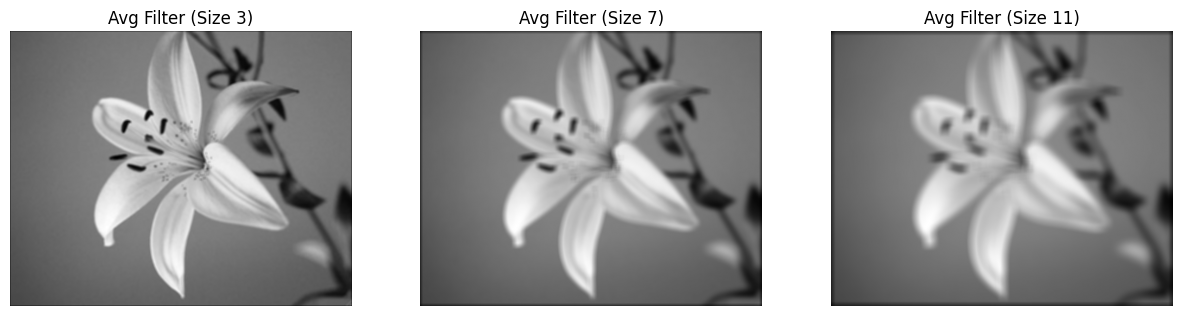

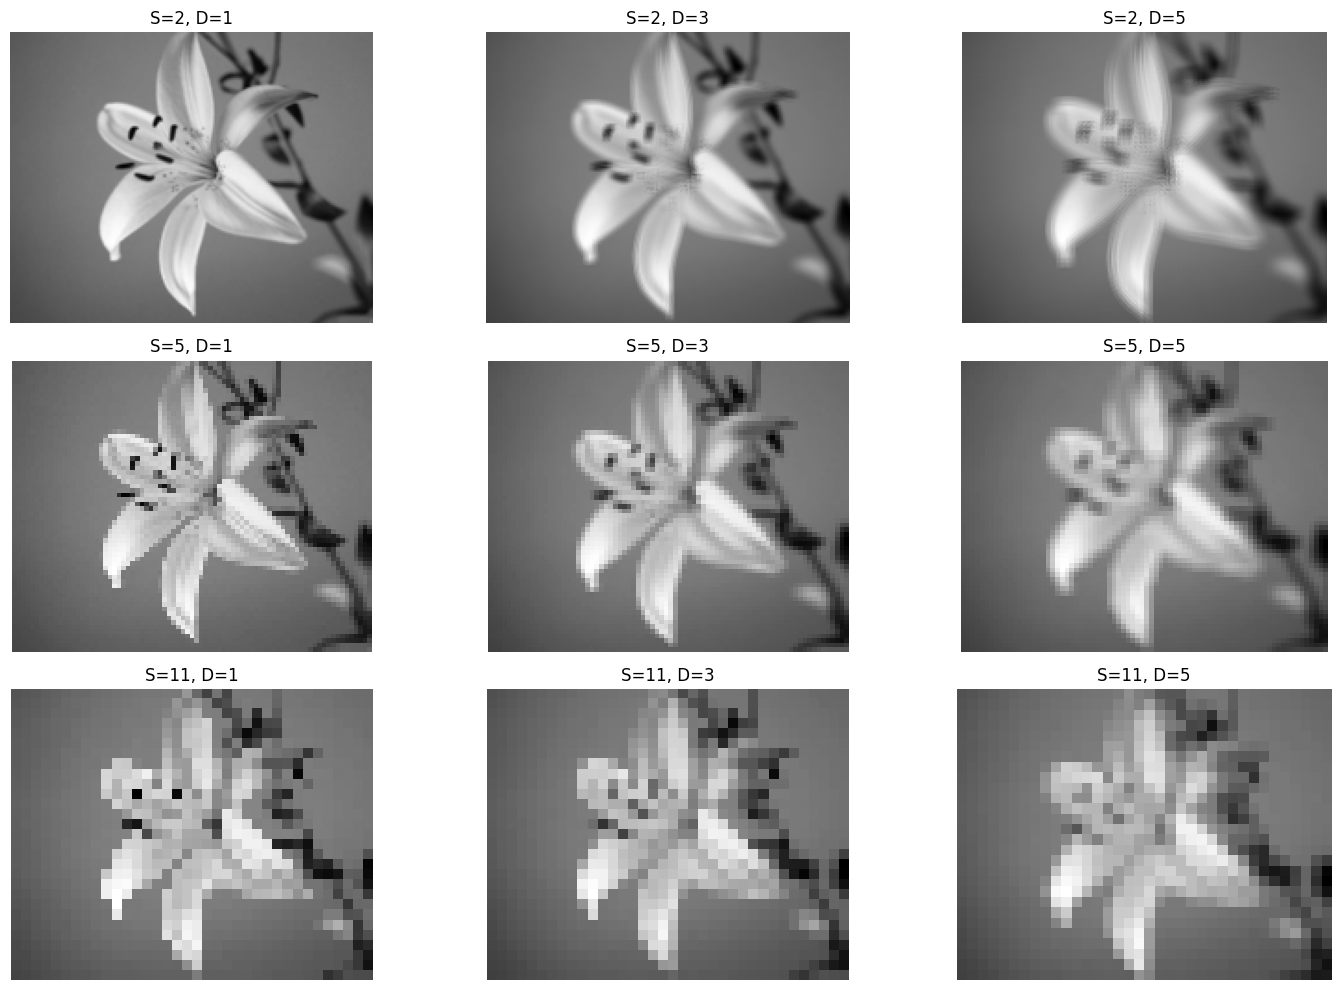

In [3]:
def create_averaging_filter(size):
    return np.ones((size, size)) / (size * size)

img_gray = cv2.imread('flower.jpg', cv2.IMREAD_GRAYSCALE)
img_gray_float = img_gray.astype(np.float64)

sizes = [3, 7, 11]
plt.figure(figsize=(15, 4))
for i, s in enumerate(sizes):
    kernel = create_averaging_filter(s)
    # Using filter_analysis or raw convolution
    filtered = tools.Conv2D(img_gray_float, kernel, padding=(s//2, s//2))
    plt.subplot(1, 3, i+1)
    plt.imshow(filtered, cmap='gray')
    plt.title(f'Avg Filter (Size {s})')
    plt.axis('off')
plt.show()

# Stride and dilation
strides = [2, 5, 11]
dilations = [1, 3, 5]
kernel = create_averaging_filter(3)
plt.figure(figsize=(15, 10))
plot_idx = 1
for st in strides:
    for dl in dilations:
        try:
            filtered = tools.Conv2D(img_gray_float, kernel, stride=(st, st), dilation=(dl, dl), padding=(0,0))
            plt.subplot(len(strides), len(dilations), plot_idx)
            plt.imshow(filtered, cmap='gray')
            plt.title(f'S={st}, D={dl}')
            plt.axis('off')
        except: pass
        plot_idx += 1
plt.tight_layout()
plt.show()


## Task 3: Color Image

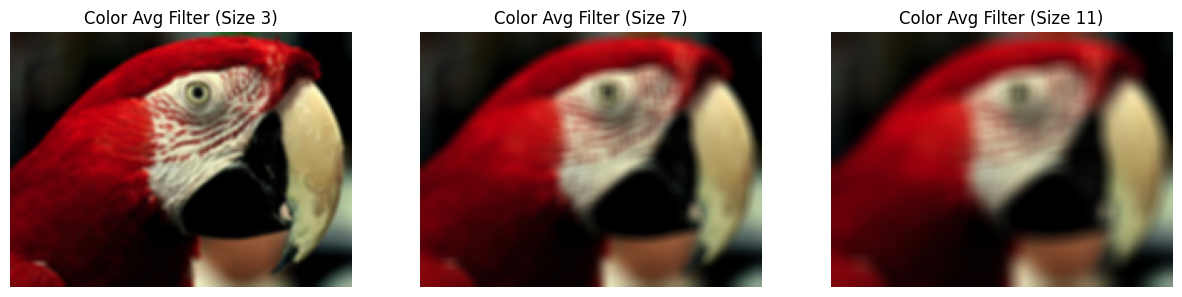

In [4]:
img_color = cv2.imread('red_bird.png', cv2.IMREAD_COLOR)
img_color_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
img_color_float = img_color_rgb.astype(np.float64)

plt.figure(figsize=(15, 4))
for i, s in enumerate(sizes):
    kernel = create_averaging_filter(s)
    filtered = cv2.filter2D(img_color_float, -1, kernel)
    plt.subplot(1, 3, i+1)
    plt.imshow(np.clip(filtered/255.0, 0, 1))
    plt.title(f'Color Avg Filter (Size {s})')
    plt.axis('off')
plt.show()


## Task 4: Gx and Gy

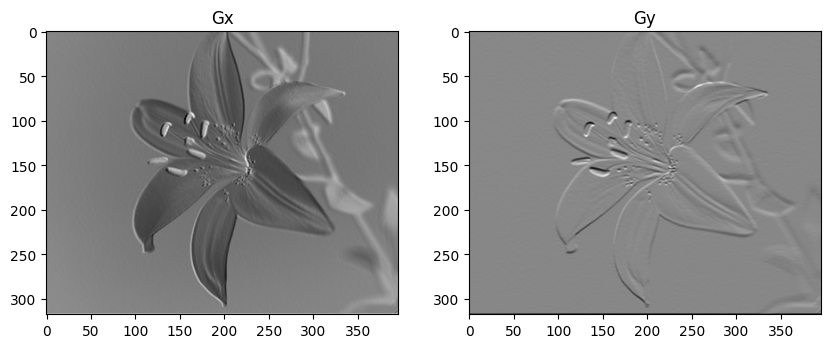

In [5]:
Gx = my_func.get_Gx(img_gray_float)
Gy = my_func.get_Gy(img_gray_float)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(Gx, cmap='gray'); plt.title('Gx')
plt.subplot(1, 2, 2); plt.imshow(Gy, cmap='gray'); plt.title('Gy')
plt.show()


## Task 5 & 6: Magnitude, Direction, and Orientation Map

c:\Users\asusz\OneDrive\Desktop\Coding\TreatImg\Lab3\my_functions_tp02.py:60: RuntimeWarning: divide by zero encountered in divide
  result=np.arctan(Gy/Gx)


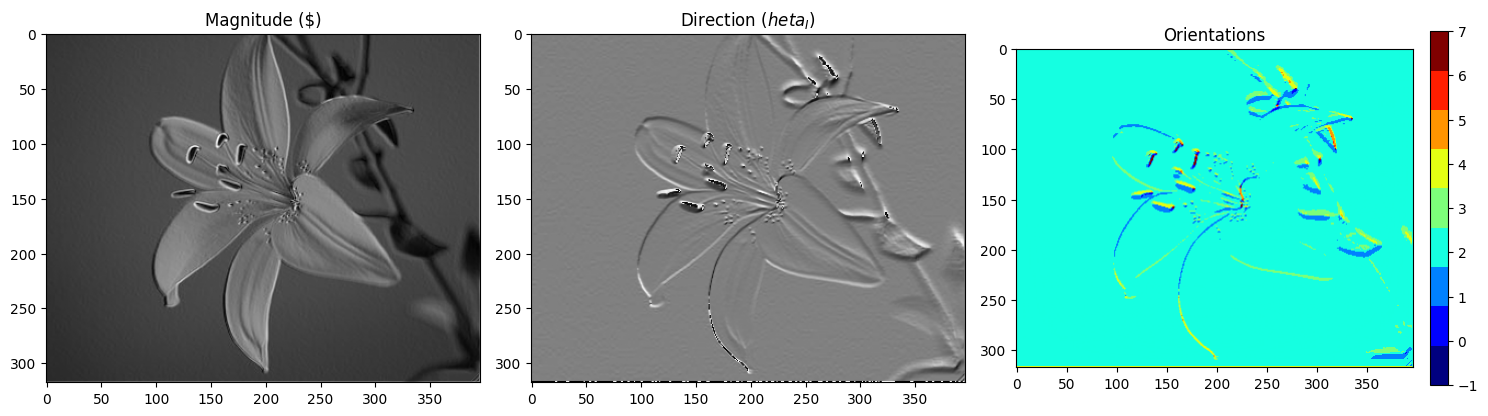

In [6]:
magnitude = my_func.module_grad(img_gray_float)
direction = my_func.direct_grad(img_gray_float)
direction = np.nan_to_num(direction)

bins = 8
angle_binned = tools.grad_orientation(Gx, Gy, magnitude, b=bins)
cmap = tools.cmap_discretize('jet', bins+1)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1); plt.imshow(magnitude, cmap='gray'); plt.title('Magnitude ($)')
plt.subplot(1, 3, 2); plt.imshow(direction, cmap='gray'); plt.title('Direction ($\theta_I$)')
plt.subplot(1, 3, 3)
img_h = plt.imshow(angle_binned, cmap=cmap, vmin=-1, vmax=bins-1)
plt.colorbar(img_h, fraction=0.046, pad=0.04)
plt.title('Orientations')
plt.tight_layout()
plt.show()


## Task 7: First-order edge detection

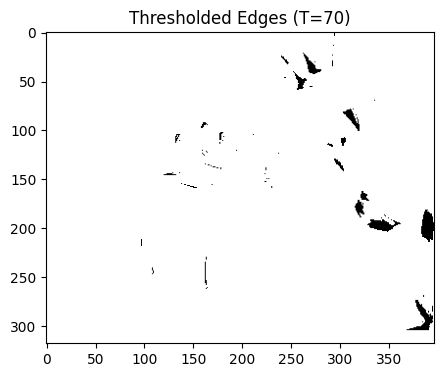

In [7]:
def first_order_edges(mag, threshold_val=50):
    edges = np.zeros_like(mag)
    edges[mag >= threshold_val] = 255
    return edges

edges_thresh = first_order_edges(magnitude, 70)
plt.figure(figsize=(5, 5))
plt.imshow(edges_thresh, cmap='gray')
plt.title('Thresholded Edges (T=70)')
plt.show()


## Task 8 & 9: Laplacian and Zero Crossings

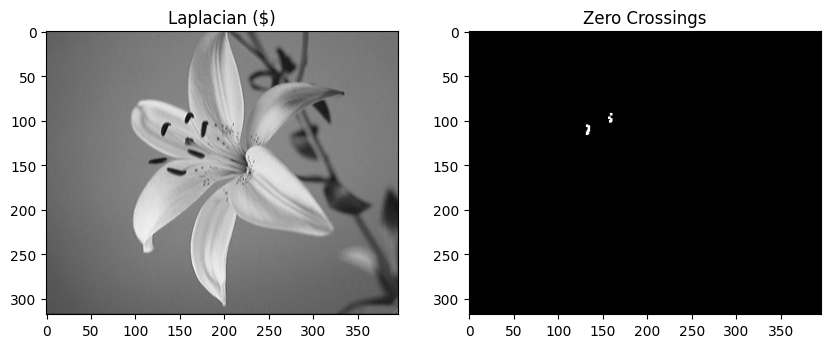

In [8]:
laplacian = my_func.get_L(img_gray_float)

def detect_zero_crossing(lap_img, threshold=10):
    zero_crossing = np.zeros_like(lap_img)
    rows, cols = lap_img.shape
    for i in range(1, rows-1):
        for j in range(1, cols-1):
            patch = lap_img[i-1:i+2, j-1:j+2]
            p_max, p_min = patch.max(), patch.min()
            if p_max > 0 and p_min < 0 and (p_max - p_min) > threshold:
                zero_crossing[i, j] = 255
    return zero_crossing

z_crossings = detect_zero_crossing(laplacian, threshold=10)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(laplacian, cmap='gray'); plt.title('Laplacian ($)')
plt.subplot(1, 2, 2); plt.imshow(z_crossings, cmap='gray'); plt.title('Zero Crossings')
plt.show()
